In [1]:
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import numpy as np

import json

In [3]:
file_path = "2025-06-25_alle_Modelle.json"


# Datei öffnen und laden
with open(file_path, 'r') as f:
    results = json.load(f)

# Alles außer body entfernen
results = results['body']

# Leere Listen anlegen
provider = []
scores = []

# Dateiinhalt durchiterieren
for i in range(0,len(results)):
    for l in range(0,len(results[i]['outputs'])):
        provider.append(results[i]['outputs'][l]['provider']) # Schreibe jeden Provider in eine Liste
        scores.append(results[i]['outputs'][l]['score']) # Schreibe jeden Score in eine Liste

provider_scores_df = pd.DataFrame(data={"Provider": provider, "scores": scores})

provider_set = set(provider) # Set mit allen Providern
provider_list = list(provider_set)

result_df = pd.DataFrame(columns=['Provider', 'Result'])

for provider in range(0, len(provider_list)):
    mean = np.mean(provider_scores_df[provider_scores_df["Provider"]==provider_list[provider]]["scores"])
    #print(f'{provider_list[provider]}: {mean}')
    result_df.loc[provider] = [provider_list[provider], mean]

print(result_df.sort_values(by="Result", ascending=False))

                                             Provider    Result
0               file://retrieve1_gemma3_4b_prompt2.py  0.701287
3   file://retrieve1_mistral-small_3-1_24b_4b_prom...  0.626915
13               file://retrieve1_qwen3_4b_prompt2.py  0.620428
2               file://retrieve1_phi_4_api_prompt2.py  0.597706
6            file://retrieve1_llama3_3_api_prompt2.py  0.572966
7             file://retrieve1_mixtral_api_prompt2.py  0.572712
15              file://retrieve1_phi_4_api_prompt1.py  0.571577
8               file://retrieve1_gemma3_4b_prompt1.py  0.556898
12               file://retrieve1_qwen3_4b_prompt1.py  0.555184
17           file://retrieve1_mixtral_8x7b_prompt2.py  0.554460
14  file://retrieve1_mistral-small_3-1_24b_4b_prom...  0.546505
11             file://retrieve1_mistral-7b_prompt2.py  0.503705
16             file://retrieve1_mistral-7b_prompt1.py  0.483684
10            file://retrieve1_mixtral_api_prompt1.py  0.478873
4            file://retrieve1_llama3_3_a

In [ ]:
def createBoxplot(daten_boxplot, labels, titles, ueberschrift):
    # Grundlegenden Aufbau definieren und zwei Variablen zuweisen
    figure, ax = plt.subplots(nrows=1, ncols=len(daten_boxplot), figsize=(60, 14))
    for i, (daten, label, title) in enumerate(zip(daten_boxplot, labels, titles)):
        # Titel setzen
        ax[i].set_title(title)
        # Skalierung fixieren
        ax[i].set_ylim(0, 1.00)
        # Linien im Hintergrund in hellgrau setzen
        ax[i].yaxis.grid(True, linestyle="-", color="lightgrey")
        # Horizontale, hellere Linien im Abstand von 0,05 ergänzen
        ax[i].set_yticks(np.arange(0, 1.00, 0.05), minor=True)
        ax[i].grid(which='minor', alpha=0.2)
        # Boxplot die Daten und Labels zuweisen
        ax[i].boxplot(daten,
                      tick_labels=label,
                      showmeans=True,
                      meanline=True,
                      meanprops=dict(color='lightseagreen'),
                      medianprops=dict(color='lightseagreen'),
                      notch=False)

    # Schriftart auf "normal" sowie die Schriftgröße auf 14 setzen
    font = {'weight': 'normal',
            'size': 14}
    plt.rc('font', **font)
    # Boxplot ausgeben
    plt.show()
    # Diagramm für als SVG-Datei unter Analysis abspeichern
    figure.savefig(f'boxplot_{ueberschrift}.svg', format="svg")

provider_list.sort()

score_list =[provider_scores_df[provider_scores_df["Provider"]==provider_list[0]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[1]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[2]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[3]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[4]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[5]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[6]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[7]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[8]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[9]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[10]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[11]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[12]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[13]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[14]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[15]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[16]]["scores"],
             provider_scores_df[provider_scores_df["Provider"]==provider_list[17]]["scores"]
]

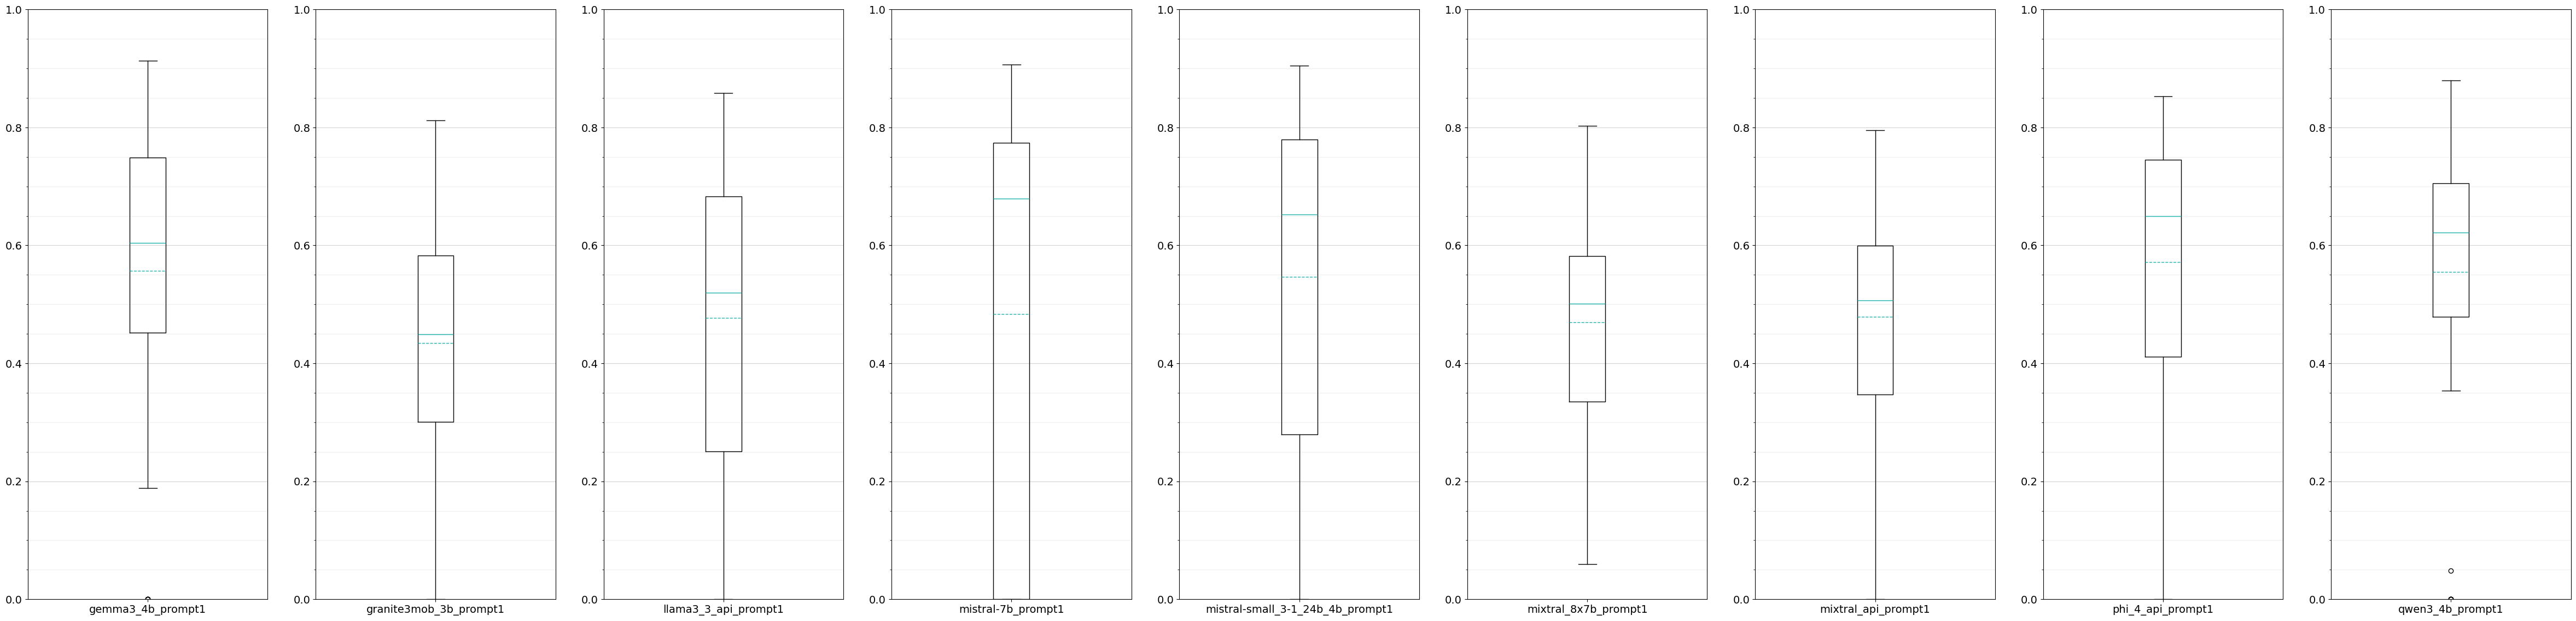

In [20]:
createBoxplot([[score_list[0]], 
               [score_list[2]],
               [score_list[4]],
               [score_list[6]],
               [score_list[8]],
               [score_list[10]],
               [score_list[12]],
               [score_list[14]],
               [score_list[16]]],
               [[provider_list[0][17:-3]],
               [provider_list[2][17:-3]],
               [provider_list[4][17:-3]],
               [provider_list[6][17:-3]],
               [provider_list[8][17:-3]],
               [provider_list[10][17:-3]],
               [provider_list[12][17:-3]],
               [provider_list[14][17:-3]],
               [provider_list[16][17:-3]]],               
               ["", "", "", "", "", "", "", "", ""],
               "Ergebnis des Prompt 1")

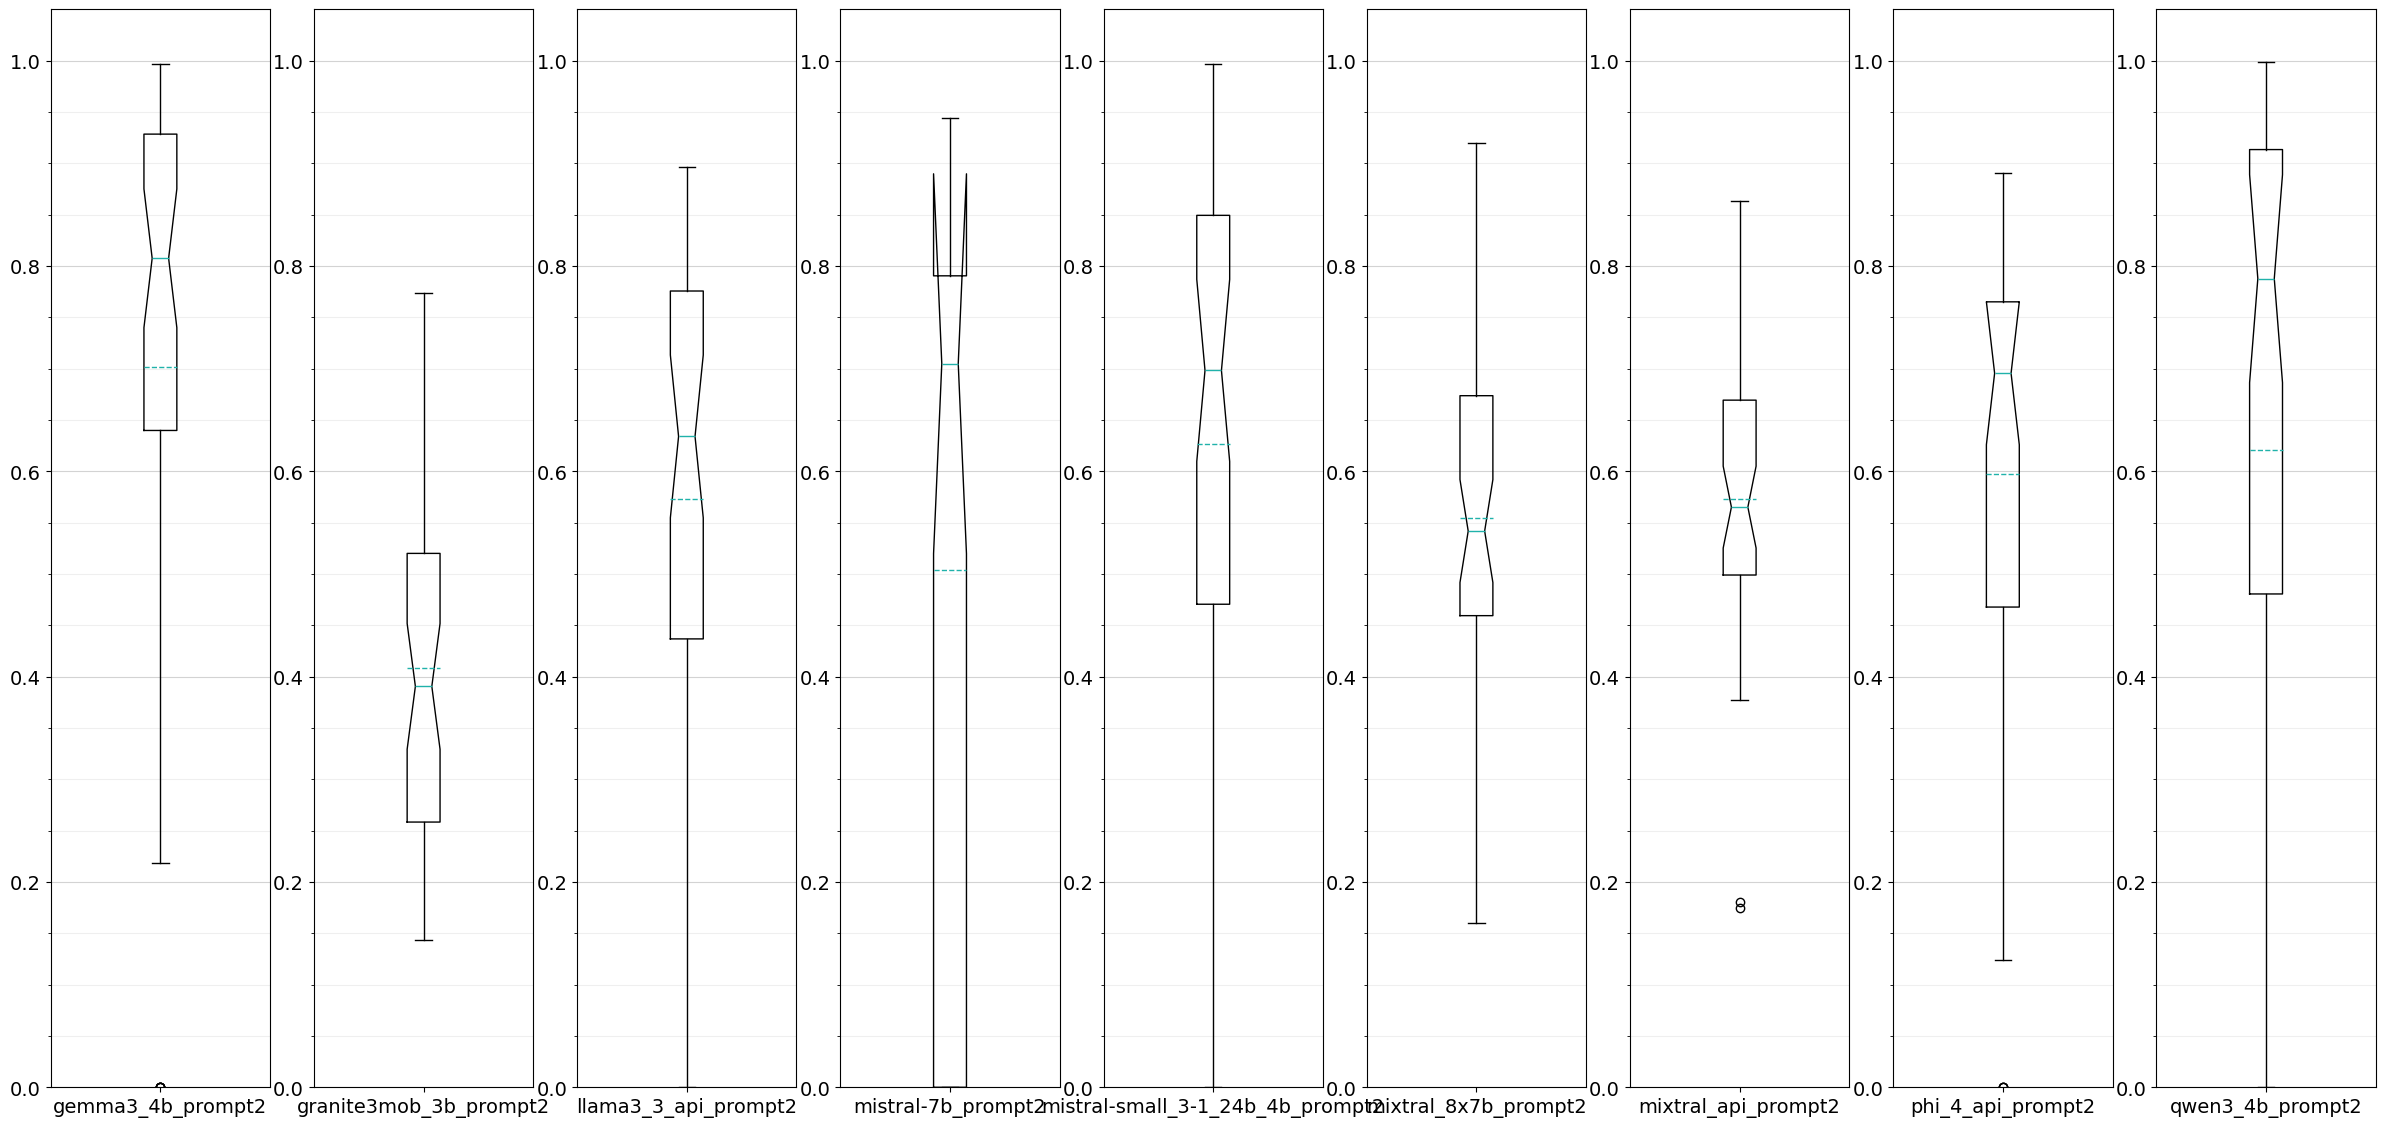

In [5]:
createBoxplot([[score_list[1]], 
               [score_list[3]],
               [score_list[5]],
               [score_list[7]],
               [score_list[9]],
               [score_list[11]],
               [score_list[13]],
               [score_list[15]],
               [score_list[17]]],
               [[provider_list[1][17:-3]],
               [provider_list[3][17:-3]],
               [provider_list[5][17:-3]],
               [provider_list[7][17:-3]],
               [provider_list[9][17:-3]],
               [provider_list[11][17:-3]],
               [provider_list[13][17:-3]],
               [provider_list[15][17:-3]],
               [provider_list[17][17:-3]]],               
               ["", "", "", "", "", "", "", "", ""],
               "Ergebnis des Prompt 2")

In [6]:
provider_list[0][17:-3]

'gemma3_4b_prompt1'